# X6Y3 LeeQ tune-up — inspection

**Hardware work paused at the owner's request on 2026-09-29. No calibration has been promoted.**

This notebook reads saved host-side data only. **Run All is safe: there are no acquisition or RPC calls in this notebook.** The separate [experiment notebook](TuneUp_X6Y3_LeeQ.ipynb) contains the protocol and opt-in acquisition cells, with hardware execution disabled by default.

Completed: three Ramsey scans on Q0 and Q1, and initial X90 ping-pong scans on both. Q1's finer X90 scan was interrupted after 42/48 saved points. Independent X calibration and candidate validation have **not** run. The original X6Y3 configuration, notebook and ZIP remain unchanged.

Frequency and amplitude estimates below are provisional. In particular, Q0's fine Ramsey scan was rejected, and neither X90 amplitude estimate has independent validation. Fit uncertainties do not capture long-term drift or model error.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

HARNESS_ROOT = Path('/local/data/projects/qubic_validation')
DATA_ROOT = HARNESS_ROOT / 'artifacts/x6y3/leeq-pingpong'
BASELINE_ROOT = HARNESS_ROOT / 'artifacts/x6y3/leeq-reproduction/hardware'

runs = {}
for directory in sorted(DATA_ROOT.iterdir()):
    if not directory.is_dir() or not (directory / 'manifest.json').exists():
        continue
    manifest = json.loads((directory / 'manifest.json').read_text())
    files = sorted(directory.glob('point-*.npz'))
    iq = np.stack([np.load(path)['iq'] for path in files]) if files else np.empty((0, 0))
    assert len(files) == manifest['completed_points'], directory.name
    analysis_path = directory / 'analysis.json'
    runs[directory.name] = dict(path=directory, manifest=manifest, iq=iq,
                               analysis=json.loads(analysis_path.read_text()) if analysis_path.exists() else None)
print(f'{len(runs)} saved scans; {sum(r["iq"].size for r in runs.values()):,} saved IQ shots')
print('Inspection only: no board connection is opened.')

9 saved scans; 509,952 saved IQ shots
Inspection only: no board connection is opened.


## Acquisition inventory

“Paused / partial” means the host acquisition was interrupted. One in-flight 1024-shot batch may have completed on the board without returning data; only successfully saved IQ is counted. The partial scan is shown for inspection and excluded from parameter estimates.

In [3]:
rows = []
for name, r in runs.items():
    m = r['manifest']
    status = 'complete' if m['status'] == 'complete' else 'paused / partial'
    rows.append({'scan': name, 'status': status, 'saved / planned points': f"{m['completed_points']} / {len(m['points'])}",
                 'saved shots': r['iq'].size, 'started UTC': m['started_utc'],
                 'source revision': m['leeq_revision'][:10]})
display(pd.DataFrame(rows).set_index('scan'))

,status,saved / planned points,saved shots,started UTC,source revision
scan,,,,,
Q0-X90-coarse,complete,48 / 48,49152,2026-09-29T05:41:44.900624+00:00,0f290428e9
Q0-ramsey-stage0,complete,60 / 60,61440,2026-09-29T05:31:58.775768+00:00,c399e3f5d2
Q0-ramsey-stage1,complete,60 / 60,61440,2026-09-29T05:34:06.415377+00:00,c399e3f5d2
Q0-ramsey-stage2,complete,60 / 60,61440,2026-09-29T05:35:51.279584+00:00,c399e3f5d2
Q1-X90-coarse,complete,48 / 48,49152,2026-09-29T05:42:58.771695+00:00,0f290428e9
Q1-X90-refine,paused / partial,42 / 48,43008,2026-09-29T05:44:15.139537+00:00,0f290428e9
Q1-ramsey-stage0,complete,60 / 60,61440,2026-09-29T05:37:23.687971+00:00,0f290428e9
Q1-ramsey-stage1,complete,60 / 60,61440,2026-09-29T05:38:46.410849+00:00,0f290428e9
Q1-ramsey-stage2,complete,60 / 60,61440,2026-09-29T05:40:21.271175+00:00,0f290428e9


## Three-scan Ramsey

The LeeQ example uses physical offsets **10, 1 and 0.1 MHz** with delay windows **0.3, 3 and 30 µs** (60 points each). The sequence is X90–delay–negative X90. Each accepted fit updates the frequency center by `set_offset − fitted_frequency` before the next scan.

The 30 µs Q0 result fails the quality guard and must not update the center. Its accepted 3 µs estimate is retained for the exploratory ping-pong scans. Q1 passes all three stages. “Accepted” here refers to the fit guard, not independent validation of a new calibration.

,offset MHz,fit MHz,fit uncertainty kHz,proposed baseline correction kHz,R²,fit accepted
scan,,,,,,
Q0-ramsey-stage0,10.0,10.22111,93.16714,-221.10603,0.89233,True
Q0-ramsey-stage1,1.0,0.98366,17.65472,-204.76123,0.74690,True
Q0-ramsey-stage2,0.1,0.00812,89.09947,-112.87833,0.39802,False
Q1-ramsey-stage0,10.0,10.04941,20.93930,-49.41219,0.99344,True
Q1-ramsey-stage1,1.0,0.90968,3.44958,40.90477,0.98702,True
Q1-ramsey-stage2,0.1,0.10838,4.53140,32.52838,0.90802,True


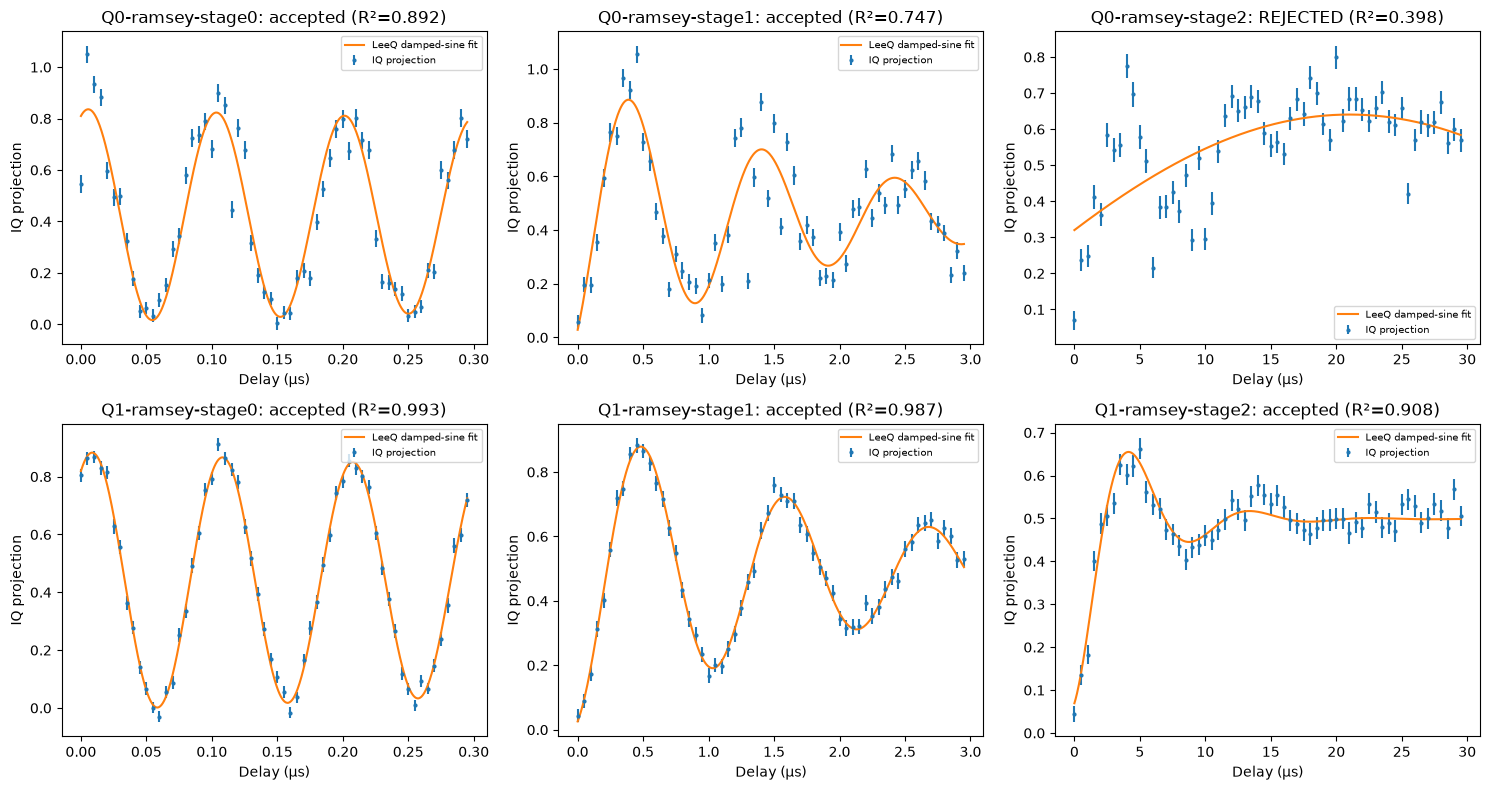

In [4]:
rows = []
for name, r in runs.items():
    if r['manifest']['experiment'] != 'leeq_ramsey' or r['analysis'] is None:
        continue
    a = r['analysis']; p = r['manifest']['points'][0]
    rows.append({'scan': name, 'offset MHz': p['set_offset_mhz'], 'fit MHz': a['frequency_mhz'],
                 'fit uncertainty kHz': 1000*a['frequency_std_mhz'],
                 'proposed baseline correction kHz': 1000*a['new_center_offset_mhz'],
                 'R²': a['r_squared'], 'fit accepted': a['accepted']})
display(pd.DataFrame(rows).set_index('scan').round(5))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for q in (0, 1):
    for stage in range(3):
        name = f'Q{q}-ramsey-stage{stage}'; r = runs[name]; a = r['analysis']
        t = np.array([p['delay_us'] for p in r['manifest']['points']])
        ax = axes[q, stage]
        ax.errorbar(t, a['mean'], yerr=a['standard_error'], fmt='.', ms=4, label='IQ projection')
        params = {key:value['value'] for key,value in a['parameters'].items()}
        xx = np.linspace(t.min(), t.max(), 600)
        yy = params['Amplitude']*np.exp(-xx/params['Decay'])*np.sin(2*np.pi*params['Frequency']*xx+params['Phase'])+params['Offset']
        ax.plot(xx, yy, label='LeeQ damped-sine fit')
        ax.set(title=f"{name}: {'accepted' if a['accepted'] else 'REJECTED'} (R²={a['r_squared']:.3f})",
               xlabel='Delay (µs)', ylabel='IQ projection')
        ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## X90 ping-pong

The notebook defines separate X90 (35 ns) and X (70 ns) FAST_DRAG pulses. We preserve those definitions and their virtual-Z corrections. For X90, repeat a multiple of four pulses followed by a fixed final X90. Pair this with the opposite final phase and randomize conditions across repeated blocks.

The graph shows the difference between paired IQ projections versus repetition count. Interpolating the amplitude where the slope is zero gives a candidate. Both initial scans use 0.98, 1.00 and 1.02 times the notebook amplitude. **Neither candidate is validated or applied.** Q0's broad uncertainty includes the original amplitude. These signals are not calibrated populations or gate fidelities.

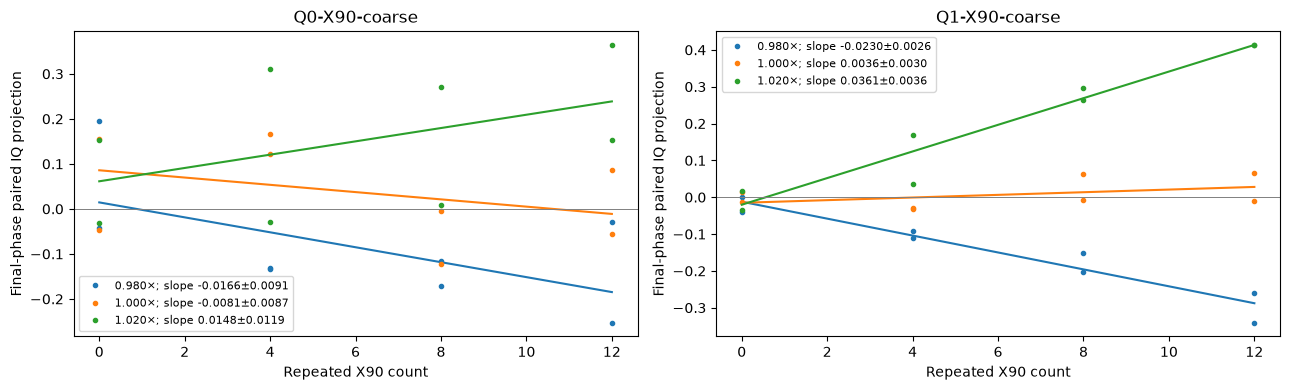

,candidate amplitude scale,fit uncertainty,bracketed,independently validated
qubit,,,,
0,1.005328,0.008558,True,False
1,0.996232,0.001179,True,False


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rows = []
for q, ax in enumerate(axes):
    name = f'Q{q}-X90-coarse'; a = runs[name]['analysis']
    rows.append({'qubit': q, 'candidate amplitude scale': a['candidate_scale'],
                 'fit uncertainty': a['candidate_std'], 'bracketed': a['bracketed'],
                 'independently validated': False})
    for c in a['curves']:
        x = np.array([p['pulse_count'] for p in c['paired_points']])
        y = np.array([p['difference'] for p in c['paired_points']])
        line, = ax.plot(x, y, '.', label=f"{c['amplitude_scale']:.3f}×; slope {c['slope']:.4f}±{c['slope_std']:.4f}")
        xx = np.array([min(x), max(x)])
        ax.plot(xx, c['slope']*xx+c['intercept'], color=line.get_color())
    ax.axhline(0, color='gray', lw=.7)
    ax.set(title=name, xlabel='Repeated X90 count', ylabel='Final-phase paired IQ projection')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows).set_index('qubit').round(6))

## Interrupted Q1 refinement — raw data only

This scan used scales 0.992/0.997/1.002 and counts 0/8/16/24. It stopped at the pause request. Only fully saved opposite-phase pairs are displayed below. No slope fit or calibration candidate is derived from this partial acquisition.

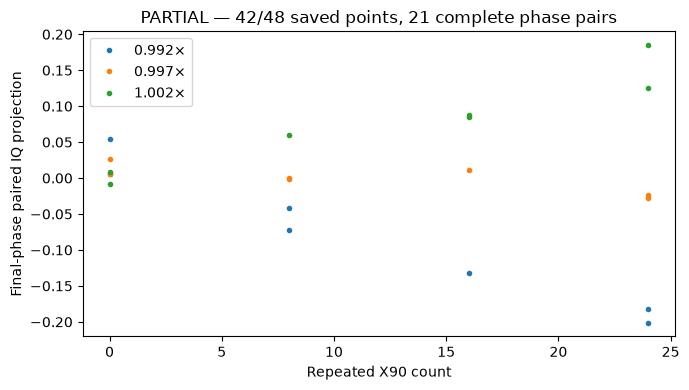

In [6]:
name = 'Q1-X90-refine'
r = runs[name]; m = r['manifest']; points = m['points'][:len(r['iq'])]
ref = json.loads((BASELINE_ROOT / 'Q1-readout/analysis.json').read_text())
centers = [complex(*p) for p in ref['iq_centers']]
projection = np.real((r['iq']-centers[0])/(centers[1]-centers[0]))
fig, ax = plt.subplots(figsize=(7, 4))
paired = 0
for scale in sorted({p['amplitude_scale'] for p in points}):
    x, y = [], []
    for i, p in enumerate(points):
        if p['amplitude_scale'] != scale or p['final_phase_rad'] != 0:
            continue
        match = [j for j, other in enumerate(points)
                 if other['amplitude_scale'] == scale and other['block'] == p['block']
                 and other['pulse_count'] == p['pulse_count'] and other['final_phase_rad'] != 0]
        if len(match) == 1:
            x.append(p['pulse_count'])
            y.append(projection[i].mean()-projection[match[0]].mean())
    paired += len(x)
    ax.plot(x, y, '.', label=f'{scale:.3f}×')
ax.set(title=f'PARTIAL — {len(points)}/48 saved points, {paired} complete phase pairs',
       xlabel='Repeated X90 count', ylabel='Final-phase paired IQ projection')
ax.legend(); fig.tight_layout(); plt.show()

## Baseline parameters and provisional frequency estimates

The accepted estimates used in the exploratory amplitude scans were −204.8 ± 17.7 kHz for Q0 and +32.5 ± 4.5 kHz for Q1 relative to the original YAML. The table shows those frequency candidates alongside the untouched amplitudes. There is no candidate YAML to apply: calibration remains paused before independent validation.

In [7]:
import yaml
baseline = yaml.safe_load((HARNESS_ROOT / 'X6Y3/configs_new/config.yaml').read_text())
rows = []
for q, stage in [(0, 1), (1, 2)]:
    ge = baseline['single_qubit'][q]['GE']; a = runs[f'Q{q}-ramsey-stage{stage}']['analysis']
    amplitudes = {gate: [p['kwargs']['amp'] for p in ge[gate]['pulse'] if p['env'] != 'virtualz'][0]
                  for gate in ('X90', 'X')}
    rows.append({'qubit': q, 'baseline MHz': ge['freq']/1e6,
                 'provisional MHz': ge['freq']/1e6+a['new_center_offset_mhz'],
                 'frequency fit uncertainty kHz': a['frequency_std_mhz']*1000,
                 'original X90 amplitude': amplitudes['X90'], 'original X amplitude': amplitudes['X']})
display(pd.DataFrame(rows).set_index('qubit').round(9))

,baseline MHz,provisional MHz,frequency fit uncertainty kHz,original X90 amplitude,original X amplitude
qubit,,,,,
0,5490.403427,5490.198666,17.654720,0.085748,0.106740
1,5377.616997,5377.649525,4.531399,0.085782,0.101185


## Pause and board check

The host process was interrupted without restarting or reconfiguring the remote service. The read-only post-check below verifies that the last submitted shot batch has ended, the same image is loaded, and RFDC clocks remain healthy. No new experiments are run by this cell.

In [8]:
post = DATA_ROOT / 'post-probe.json'
if post.exists():
    check = json.loads(post.read_text())
    display(pd.Series({'loaded image': check['gitrevision_hex'], 'boot ID': check['boot_id'],
                       'download performed': check['download_performed'],
                       'last batch complete': bool(check['registers']['lastshotdone']),
                       'all RFDC clocks healthy': all(v['status']['DataPathClocksStatus']==1 for v in check['rfdc']),
                       'RFDC FIFO flags clear': all(v['status']['IsFIFOFlagsAsserted']==0 for v in check['rfdc'])}))
else:
    print('Post-check not available; inspect pause-board-check.log.')

loaded image                                           aa01c78f
boot ID                    8c965eeb-32dc-4def-8891-22a72510753c
download performed                                        False
last batch complete                                        True
all RFDC clocks healthy                                    True
RFDC FIFO flags clear                                      True
dtype: object

## Next steps after an explicit resume

1. Review Q0 scatter and the rejected fine Ramsey fit.
2. Acquire a fresh complete X90 refinement scan; do not treat the interrupted Q1 scan as complete.
3. Validate X90 candidates against the original amplitudes in fresh randomized blocks.
4. Tune the independent X pulses, then recheck Ramsey at the selected amplitudes.
5. Save independently validated settings in a separate local candidate YAML.

The experiment code is in [TuneUp_X6Y3_LeeQ.ipynb](TuneUp_X6Y3_LeeQ.ipynb) and [x6y3_tuneup.py](../../leeq/experiments/x6y3_tuneup.py). Full raw IQ, manifests and logs remain under `DATA_ROOT`. No board work should resume from this notebook.